# PD Projection — IFRS 9 Lifetime PD & ECL

Applies the fitted discrete-time logistic hazard model to a loan portfolio
under three macro scenarios to produce IFRS 9-consistent PD and ECL estimates.

**Inputs:**
- `model_params.json` — fitted logistic hazard model coefficients
- `scenarios.csv` — quarterly macro paths (baseline, mild, severe)
- `full_panel.parquet` — loan panel (used to extract current portfolio snapshot)

**Outputs:**
- `lifetime_pd.csv` — per-loan lifetime PD under each scenario
- `ecl_summary.csv` — portfolio ECL summary

**IFRS 9 mechanics:**
- **12-month PD**: probability of default in the next 4 quarters
- **Lifetime PD**: probability of default at any point over remaining loan life
  using survival-weighted hazard chain
- **ECL**: probability-weighted average across scenarios × LGD × EAD
- **Scenario weights**: 50% baseline, 30% mild, 20% severe

## 1. Imports

In [1]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print('Libraries loaded.')

Libraries loaded.


## 2. Load Model Parameters

In [2]:
with open('model_params.json') as f:
    mp = json.load(f)

params = pd.Series(mp['params'])

# Model constants
INTERCEPT_CORRECTION = -2.316088   # WESML log(tau) correction
LOAN_FEATURES        = ['LTV', 'DTI', 'FICO']
MACRO_FEATURES       = [
    'unemployment_rate_log_diff_4_lag2',
    'hpi_cs_log_diff_1_lag2',
    'real_gdp_log_diff_4',
]
AGE_BINS   = [0, 6, 12, 24, 60, 120, 9999]
AGE_LABELS = ['0-6', '6-12', '12-24', '24-60', '60-120', '120+']

print('Model coefficients:')
for k, v in params.items():
    print(f'  {k:<45}: {v:+.6f}')
print(f'\nIntercept correction: {INTERCEPT_CORRECTION}')
print(f'Pseudo R2: {mp["prsquared"]:.4f}')
print(f'Converged: {mp["converged"]}')

Model coefficients:
  const                                        : -1.760730
  LTV                                          : +0.016621
  DTI                                          : +0.016894
  FICO                                         : -0.007175
  unemployment_rate_log_diff_4_lag2            : +0.012544
  hpi_cs_log_diff_1_lag2                       : -0.018319
  real_gdp_log_diff_4                          : -0.030595
  age_6-12                                     : +0.661514
  age_12-24                                    : +1.148918
  age_24-60                                    : +1.462147
  age_60-120                                   : +1.555352
  age_120+                                     : +1.719247

Intercept correction: -2.316088
Pseudo R2: 0.0652
Converged: True


## 3. Load Macro Scenarios

In [3]:
scenarios_raw = pd.read_csv(
    'scenarios.csv',
    index_col=0,
    parse_dates=True
)
scenarios_raw.index.name = 'quarter'

SCENARIO_NAMES   = ['baseline', 'mild', 'severe']
SCENARIO_WEIGHTS = {'baseline': 0.50, 'mild': 0.30, 'severe': 0.20}

scenarios = {
    name: scenarios_raw[scenarios_raw['scenario'] == name][MACRO_FEATURES].copy()
    for name in SCENARIO_NAMES
}

print('Scenario paths loaded:')
for name, df in scenarios.items():
    print(f'  {name:<10}: {len(df)} quarters  '
          f'({df.index.min().date()} to {df.index.max().date()})')

print(f'\nScenario weights: {SCENARIO_WEIGHTS}')
print(f'\nFirst 4 quarters of each scenario:')
for name, df in scenarios.items():
    print(f'\n{name}:')
    print(df.head(4).round(4).to_string())

Scenario paths loaded:
  baseline  : 120 quarters  (2025-10-01 to 2055-07-01)
  mild      : 120 quarters  (2025-10-01 to 2055-07-01)
  severe    : 120 quarters  (2025-10-01 to 2055-07-01)

Scenario weights: {'baseline': 0.5, 'mild': 0.3, 'severe': 0.2}

First 4 quarters of each scenario:

baseline:
            unemployment_rate_log_diff_4_lag2  hpi_cs_log_diff_1_lag2  real_gdp_log_diff_4
quarter                                                                                   
2025-10-01                             7.2205                  1.3398               2.1531
2026-01-01                             6.5159                  0.8396               2.2211
2026-04-01                             6.3924                  0.8847               2.2211
2026-07-01                             5.8345                  1.0253               2.1877

mild:
            unemployment_rate_log_diff_4_lag2  hpi_cs_log_diff_1_lag2  real_gdp_log_diff_4
quarter                                                 

## 4. Load 2025Q3 New Vintage Portfolio

In [4]:
# Performance file column layout (pipe-delimited, no header)
# 1=ID, 2=Date, 11=UPB, 15=Age, 19=LTV, 22=DTI, 23=FICO

ACQ_FILE = '2025Q3.csv'

print(f'Loading {ACQ_FILE}...')
raw = pd.read_csv(
    ACQ_FILE,
    sep='|',
    header=None,
    usecols=[1, 15, 19, 22, 23],
    dtype={1: str, 15: 'float32', 19: 'float32', 22: 'float32', 23: 'float32'}
).rename(columns={1: 'ID', 15: 'Age', 19: 'LTV', 22: 'DTI', 23: 'FICO'})

print(f'Raw rows: {len(raw):,}')

# New vintage: take only age = 3 months (first quarterly observation)
portfolio = raw[raw['Age'] == 3].copy()

# Clean
portfolio['FICO'] = portfolio['FICO'].replace(9999, np.nan)
portfolio = portfolio.dropna(subset=['LTV', 'DTI', 'FICO']).copy()
portfolio = portfolio[(portfolio['LTV'] > 0) & (portfolio['LTV'] <= 97)].copy()
portfolio = portfolio[portfolio['DTI'] <= 65].copy()
portfolio = portfolio.reset_index(drop=True)

# Set reference quarter
REF_DATE = pd.Timestamp('2025-07-01')
portfolio['q'] = REF_DATE

print(f'New vintage loans (age=3): {len(portfolio):,}')
print()
print('Portfolio characteristics:')
print(portfolio[['LTV', 'DTI', 'FICO']].describe().round(1).to_string())

Loading 2025Q3.csv...
Raw rows: 532,607
New vintage loans (age=3): 24,136

Portfolio characteristics:
           LTV      DTI     FICO
count  24136.0  24136.0  24136.0
mean      75.0     37.9    756.6
std       20.3      9.1     45.1
min        5.0      3.0    534.0
25%       64.0     32.0    729.0
50%       80.0     40.0    768.0
75%       93.0     45.0    793.0
max       97.0     50.0    832.0


## 5. Prediction Function

Computes one-quarter-ahead conditional PD for a loan given its current
characteristics and macro conditions at that quarter.

**Age bucketing**: age enters as categorical dummies relative to the
0-6 month base category. Age advances by 1 quarter at each projection step.

In [5]:
def age_dummies(age_series):
    """Convert continuous age (quarters) to age bucket dummies."""
    buckets = pd.cut(
        age_series, bins=AGE_BINS, labels=AGE_LABELS,
        right=True, include_lowest=True
    )
    dummies = pd.get_dummies(buckets, dtype=float)
    # Ensure all expected columns present, drop base category
    for col in AGE_LABELS:
        if col not in dummies.columns:
            dummies[col] = 0.0
    dummies = dummies[AGE_LABELS[1:]]  # drop 0-6 (base)
    dummies.columns = [f'age_{c}' for c in dummies.columns]
    return dummies


def predict_pd_quarter(loans_df, macro_row):
    """
    Predict one-quarter conditional PD for a batch of loans.

    Parameters
    ----------
    loans_df : DataFrame with columns LTV, DTI, FICO, Age
    macro_row : Series with macro variable values for this quarter

    Returns
    -------
    np.array of PD values, one per loan
    """
    n = len(loans_df)

    # Build feature matrix
    X = pd.DataFrame(index=loans_df.index)
    X['const'] = 1.0
    X['LTV']   = loans_df['LTV'].values
    X['DTI']   = loans_df['DTI'].values
    X['FICO']  = loans_df['FICO'].values

    # Macro features -- same value for all loans this quarter
    for feat in MACRO_FEATURES:
        X[feat] = float(macro_row[feat])

    # Age dummies
    age_d = age_dummies(loans_df['Age'].values)
    age_d.index = loans_df.index
    X = pd.concat([X, age_d], axis=1)

    # Align to model params order
    X = X[params.index]

    # Log-odds with intercept correction
    log_odds = X.values @ params.values + INTERCEPT_CORRECTION
    return 1.0 / (1.0 + np.exp(-log_odds))


# Quick sanity check
test_loan = portfolio.iloc[:5].copy()
test_macro = scenarios['baseline'].iloc[0]
test_pd = predict_pd_quarter(test_loan, test_macro)
print('Sanity check -- 5 sample loans, baseline Q1 PD:')
for i, (_, row) in enumerate(test_loan.iterrows()):
    print(f'  LTV={row["LTV"]:.0f}  DTI={row["DTI"]:.0f}  '
          f'FICO={row["FICO"]:.0f}  Age={row["Age"]:.0f}q  '
          f'-> PD={test_pd[i]*100:.4f}%')

Sanity check -- 5 sample loans, baseline Q1 PD:
  LTV=80  DTI=45  FICO=787  Age=3q  -> PD=0.0484%
  LTV=90  DTI=33  FICO=803  Age=3q  -> PD=0.0416%
  LTV=53  DTI=45  FICO=731  Age=3q  -> PD=0.0462%
  LTV=56  DTI=21  FICO=729  Age=3q  -> PD=0.0328%
  LTV=80  DTI=39  FICO=759  Age=3q  -> PD=0.0534%


## 6. Lifetime PD Projection

For each loan and each scenario, project the discrete-time hazard forward
quarter by quarter over the remaining loan life.

**IFRS 9 lifetime PD formula:**
```
PD_lifetime = sum_t [ h_t * S_{t-1} ]
```
where:
- `h_t` = conditional default probability at quarter t (from logit model)
- `S_{t-1}` = survival probability to start of quarter t
- `S_t = S_{t-1} * (1 - h_t)` (updated each quarter)

**12-month PD**: same formula restricted to first 4 quarters.

**Remaining life**: capped at `MAX_AGE - current_age` quarters.
Loans beyond MAX_AGE are treated as at the final age bucket.

In [6]:
MAX_AGE      = 360   # 30 years in months / ~120 quarters
MAX_QUARTERS = 120   # projection horizon matches scenario paths


def project_lifetime_pd(portfolio, scenario_paths, max_quarters=MAX_QUARTERS):
    """
    Project lifetime PD and 12-month PD for each loan under one scenario.

    Parameters
    ----------
    portfolio      : DataFrame with current loan characteristics
    scenario_paths : DataFrame indexed by quarter with macro variables
    max_quarters   : maximum projection horizon

    Returns
    -------
    DataFrame with columns: ID, pd_12m, pd_lifetime
    """
    scenario_quarters = scenario_paths.index.tolist()
    n_loans           = len(portfolio)

    # Pre-allocate accumulators
    pd_12m_acc      = np.zeros(n_loans)
    pd_lifetime_acc = np.zeros(n_loans)
    survival        = np.ones(n_loans)

    # Current loan state -- will update age each quarter
    loans = portfolio[['LTV', 'DTI', 'FICO', 'Age']].copy().reset_index(drop=True)

    n_proj = min(max_quarters, len(scenario_quarters))

    for t in range(n_proj):
        macro_row = scenario_paths.iloc[t]

        # Conditional PD this quarter
        h_t = predict_pd_quarter(loans, macro_row)

        # Marginal contribution to lifetime PD
        contribution = h_t * survival
        pd_lifetime_acc += contribution

        # 12-month PD: first 4 quarters only
        if t < 4:
            pd_12m_acc += contribution

        # Update survival
        survival *= (1.0 - h_t)

        # Advance age by 1 quarter (3 months)
        loans['Age'] = loans['Age'] + 3

        # Early exit: if all loans have < 0.001% remaining survival
        if survival.max() < 1e-5:
            break

    result = pd.DataFrame({
        'ID':          portfolio['ID'].values,
        'pd_12m':      pd_12m_acc,
        'pd_lifetime': pd_lifetime_acc,
    })
    return result


print('Projecting lifetime PD under each scenario...')
print(f'Portfolio: {len(portfolio):,} loans')
print(f'Horizon: {MAX_QUARTERS} quarters')
print()

scenario_results = {}
for name in SCENARIO_NAMES:
    print(f'  Running {name}...')
    res = project_lifetime_pd(portfolio, scenarios[name])
    scenario_results[name] = res
    print(f'    Mean 12m PD:       {res["pd_12m"].mean()*100:.4f}%')
    print(f'    Mean lifetime PD:  {res["pd_lifetime"].mean()*100:.4f}%')
    print(f'    Max lifetime PD:   {res["pd_lifetime"].max()*100:.2f}%')

Projecting lifetime PD under each scenario...
Portfolio: 24,136 loans
Horizon: 120 quarters

  Running baseline...
    Mean 12m PD:       0.3258%
    Mean lifetime PD:  26.2953%
    Max lifetime PD:   83.77%
  Running mild...
    Mean 12m PD:       0.3592%
    Mean lifetime PD:  27.0669%
    Max lifetime PD:   84.79%
  Running severe...
    Mean 12m PD:       0.3799%
    Mean lifetime PD:  27.9988%
    Max lifetime PD:   85.95%


## 7. IFRS 9 ECL Calculation

IFRS 9 Expected Credit Loss:
```
ECL = sum_scenarios [ weight_s * PD_s * LGD * EAD ]
```

**LGD assumption**: 40% flat (conservative unsecured proxy;
in practice would be LTV-dependent for mortgages).

**EAD assumption**: current outstanding balance proxied by
funded amount at origination (consistent with Fannie Mae data).
For simplicity, EAD = 1.0 (normalised) — ECL is expressed as
a fraction of outstanding balance.

**Stage classification (IFRS 9 staging):**
- Stage 1: 12-month ECL (no significant credit deterioration)
- Stage 2: Lifetime ECL (significant increase in credit risk)
- Stage 3: Lifetime ECL (credit-impaired)

For simplicity all loans are treated as Stage 1/2 using lifetime PD.

In [7]:
LGD = 0.40   # flat LGD assumption
EAD = 1.00   # normalised; multiply by actual balance in production

# Probability-weighted PD across scenarios
pd_12m_weighted      = sum(
    SCENARIO_WEIGHTS[name] * scenario_results[name]['pd_12m'].values
    for name in SCENARIO_NAMES
)
pd_lifetime_weighted = sum(
    SCENARIO_WEIGHTS[name] * scenario_results[name]['pd_lifetime'].values
    for name in SCENARIO_NAMES
)

# ECL
ecl_12m      = pd_12m_weighted      * LGD * EAD
ecl_lifetime = pd_lifetime_weighted * LGD * EAD

# Compile results
results_df = portfolio[['ID', 'LTV', 'DTI', 'FICO', 'Age']].copy().reset_index(drop=True)

for name in SCENARIO_NAMES:
    results_df[f'pd_12m_{name}']      = scenario_results[name]['pd_12m'].values
    results_df[f'pd_lifetime_{name}'] = scenario_results[name]['pd_lifetime'].values

results_df['pd_12m_weighted']      = pd_12m_weighted
results_df['pd_lifetime_weighted'] = pd_lifetime_weighted
results_df['ecl_12m']              = ecl_12m
results_df['ecl_lifetime']         = ecl_lifetime

print('=== IFRS 9 ECL Summary ===')
print(f'LGD assumption : {LGD:.0%}')
print(f'Scenario weights: {SCENARIO_WEIGHTS}')
print()
print(f'{'Metric':<35} {'Baseline':>10} {'Mild':>10} {'Severe':>10} {'Weighted':>10}')
print('-' * 75)
for label, key in [('Mean 12m PD', 'pd_12m'), ('Mean Lifetime PD', 'pd_lifetime')]:
    vals = [scenario_results[n][key].mean()*100 for n in SCENARIO_NAMES]
    if key == 'pd_12m':
        w = pd_12m_weighted.mean()*100
    else:
        w = pd_lifetime_weighted.mean()*100
    print(f'{label:<35} {vals[0]:>9.4f}% {vals[1]:>9.4f}% {vals[2]:>9.4f}% {w:>9.4f}%')

print()
print(f'{'Mean 12m ECL (% of balance)':<35} {ecl_12m.mean()*100:>9.4f}%')
print(f'{'Mean Lifetime ECL (% of balance)':<35} {ecl_lifetime.mean()*100:>9.4f}%')
print(f'{'Total portfolio lifetime ECL':<35} {ecl_lifetime.sum():.2f} (normalised units)')

=== IFRS 9 ECL Summary ===
LGD assumption : 40%
Scenario weights: {'baseline': 0.5, 'mild': 0.3, 'severe': 0.2}

Metric                                Baseline       Mild     Severe   Weighted
---------------------------------------------------------------------------
Mean 12m PD                            0.3258%    0.3592%    0.3799%    0.3466%
Mean Lifetime PD                      26.2953%   27.0669%   27.9988%   26.8675%

Mean 12m ECL (% of balance)            0.1387%
Mean Lifetime ECL (% of balance)      10.7470%
Total portfolio lifetime ECL        2593.90 (normalised units)


## 8. Diagnostics

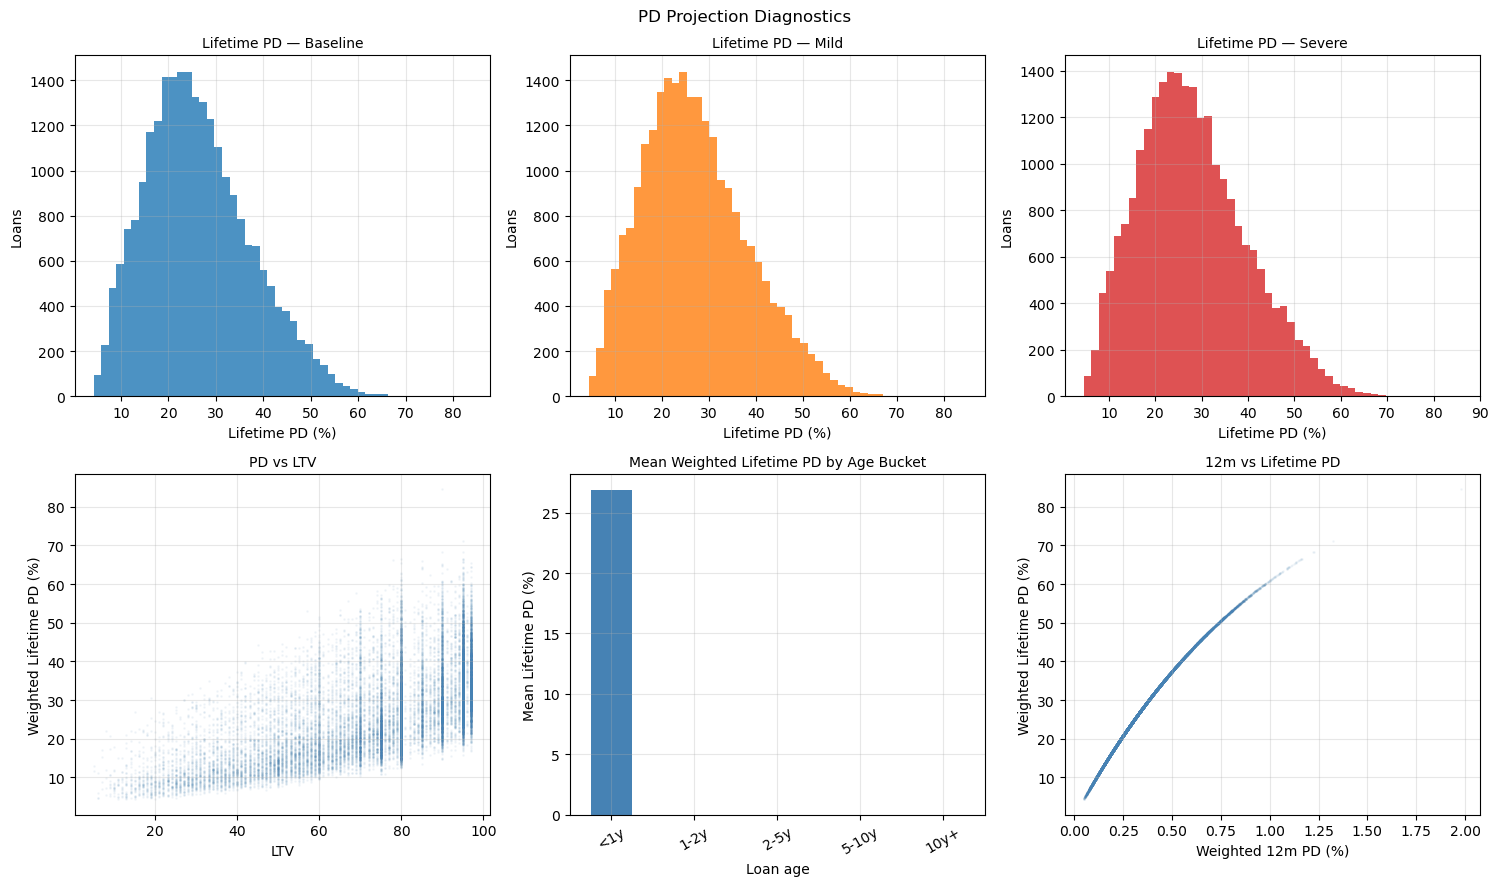

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

# Row 1: PD distributions per scenario
for col, name in enumerate(SCENARIO_NAMES):
    ax = axes[0, col]
    ax.hist(scenario_results[name]['pd_lifetime'] * 100,
            bins=50, edgecolor='none', alpha=0.8, color=
            ['tab:blue', 'tab:orange', 'tab:red'][col])
    ax.set_title(f'Lifetime PD — {name.capitalize()}', fontsize=10)
    ax.set_xlabel('Lifetime PD (%)')
    ax.set_ylabel('Loans')
    ax.grid(True, alpha=0.3)

# Row 2: PD vs LTV, PD vs Age, 12m vs lifetime scatter
ax = axes[1, 0]
ax.scatter(results_df['LTV'], results_df['pd_lifetime_weighted'] * 100,
           alpha=0.05, s=1, color='steelblue')
ax.set_xlabel('LTV')
ax.set_ylabel('Weighted Lifetime PD (%)')
ax.set_title('PD vs LTV', fontsize=10)
ax.grid(True, alpha=0.3)

ax = axes[1, 1]
age_bins_plot = pd.cut(results_df['Age'], bins=[0,12,24,60,120,9999],
                       labels=['<1y','1-2y','2-5y','5-10y','10y+'])
pd_by_age = results_df.groupby(age_bins_plot)['pd_lifetime_weighted'].mean() * 100
pd_by_age.plot(kind='bar', ax=ax, color='steelblue', edgecolor='none')
ax.set_title('Mean Weighted Lifetime PD by Age Bucket', fontsize=10)
ax.set_xlabel('Loan age')
ax.set_ylabel('Mean Lifetime PD (%)')
ax.tick_params(axis='x', rotation=30)
ax.grid(True, alpha=0.3)

ax = axes[1, 2]
ax.scatter(results_df['pd_12m_weighted'] * 100,
           results_df['pd_lifetime_weighted'] * 100,
           alpha=0.05, s=1, color='steelblue')
ax.set_xlabel('Weighted 12m PD (%)')
ax.set_ylabel('Weighted Lifetime PD (%)')
ax.set_title('12m vs Lifetime PD', fontsize=10)
ax.grid(True, alpha=0.3)

fig.suptitle('PD Projection Diagnostics', fontsize=12)
fig.tight_layout()
plt.show()

## 9. Scenario Comparison

Computing average quarterly hazard paths...


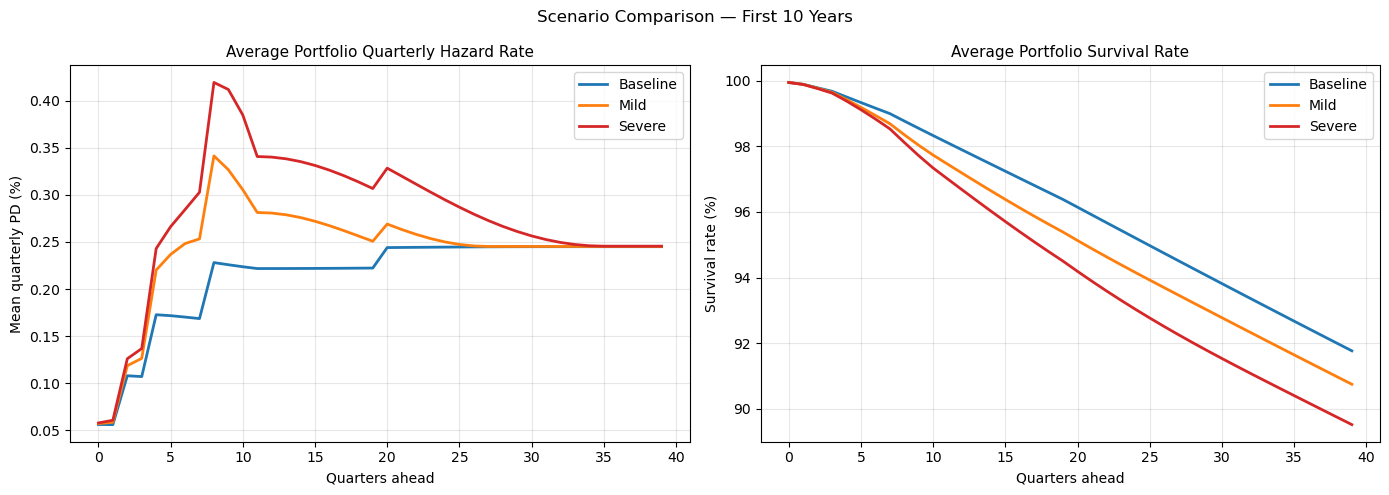

In [9]:
# Average quarterly hazard rate over projection horizon
print('Computing average quarterly hazard paths...')

N_PLOT   = 40  # 10 years
avg_hazard = {name: [] for name in SCENARIO_NAMES}

for name in SCENARIO_NAMES:
    loans = portfolio[['LTV', 'DTI', 'FICO', 'Age']].copy().reset_index(drop=True)
    for t in range(N_PLOT):
        macro_row = scenarios[name].iloc[t]
        h_t = predict_pd_quarter(loans, macro_row)
        avg_hazard[name].append(h_t.mean() * 100)
        loans['Age'] = loans['Age'] + 3

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: average quarterly hazard rate
ax = axes[0]
colors = {'baseline': 'tab:blue', 'mild': 'tab:orange', 'severe': 'tab:red'}
for name in SCENARIO_NAMES:
    ax.plot(avg_hazard[name], label=name.capitalize(),
            color=colors[name], linewidth=2)
ax.set_xlabel('Quarters ahead')
ax.set_ylabel('Mean quarterly PD (%)')
ax.set_title('Average Portfolio Quarterly Hazard Rate', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

# Right: cumulative survival
ax = axes[1]
for name in SCENARIO_NAMES:
    cumhaz = np.array(avg_hazard[name]) / 100
    surv   = np.cumprod(1 - cumhaz) * 100
    ax.plot(surv, label=name.capitalize(),
            color=colors[name], linewidth=2)
ax.set_xlabel('Quarters ahead')
ax.set_ylabel('Survival rate (%)')
ax.set_title('Average Portfolio Survival Rate', fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3)

fig.suptitle('Scenario Comparison — First 10 Years', fontsize=12)
fig.tight_layout()
plt.show()

## 10. Save

In [ ]:
# Lifetime PD per loan
results_df.to_csv('lifetime_pd.csv', index=False)
print('Saved: lifetime_pd.csv')
print(f'  Shape: {results_df.shape}')
print(f'  Columns: {results_df.columns.tolist()}')

# Portfolio ECL summary
ecl_summary = pd.DataFrame({
    'metric': [
        'n_loans',
        'mean_pd_12m_baseline', 'mean_pd_12m_mild', 'mean_pd_12m_severe',
        'mean_pd_12m_weighted',
        'mean_pd_lifetime_baseline', 'mean_pd_lifetime_mild', 'mean_pd_lifetime_severe',
        'mean_pd_lifetime_weighted',
        'lgd_assumption',
        'mean_ecl_12m', 'mean_ecl_lifetime',
        'scenario_weight_baseline', 'scenario_weight_mild', 'scenario_weight_severe',
    ],
    'value': [
        len(results_df),
        scenario_results['baseline']['pd_12m'].mean(),
        scenario_results['mild']['pd_12m'].mean(),
        scenario_results['severe']['pd_12m'].mean(),
        pd_12m_weighted.mean(),
        scenario_results['baseline']['pd_lifetime'].mean(),
        scenario_results['mild']['pd_lifetime'].mean(),
        scenario_results['severe']['pd_lifetime'].mean(),
        pd_lifetime_weighted.mean(),
        LGD,
        ecl_12m.mean(),
        ecl_lifetime.mean(),
        SCENARIO_WEIGHTS['baseline'],
        SCENARIO_WEIGHTS['mild'],
        SCENARIO_WEIGHTS['severe'],
    ]
})
ecl_summary.to_csv('ecl_summary.csv', index=False)
print('Saved: ecl_summary.csv')

print('\n=== Final Summary ===')
print(ecl_summary.to_string(index=False))